# XGBoost-v6 Price Forecast (t+5, Event-Based)

Notebook ini mencoba **model XGBoost untuk prediksi harga** (Close t+5) sebagai eksperimen terpisah dari model directional.


## Tujuan dan Batasan

- Target utama: `Close(t+5)`.
- Teknik model: XGBoost regresi pada `log-return t+5`, lalu dikonversi ke harga.
- Evaluasi: baseline lock (pilih baseline di valid, lock ke test), purged split, yearly walk-forward.
- Catatan: notebook ini fokus **uji kelayakan model harga**, bukan jaminan outperform mutlak.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    plt.style.use("seaborn-v0_8-whitegrid")

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "processed data" / "ali_f_event_model_ready_v3.csv"
OUT_DIR = ROOT / "data" / "processed data"

SEED = 42
H = 5
START_DATE = "2020-01-01"
DROP_LONG_GAP = True
TRAIN_WINDOW_YEARS = 3
MIN_TRAIN_ROWS = 180
MIN_VALID_ROWS = 80
MIN_TEST_ROWS = 80
MIN_TRAIN_YEARS = 2
EARLY_STOPPING = 100
ALPHA_GRID = [0.2, 0.4, 0.6, 0.8, 1.0]

REG_PARAMS = {
    "objective": "reg:squarederror",
    "n_estimators": 1000,
    "learning_rate": 0.03,
    "max_depth": 4,
    "min_child_weight": 5,
    "subsample": 0.95,
    "colsample_bytree": 0.95,
    "reg_alpha": 0.2,
    "reg_lambda": 2.5,
}

print("DATA_PATH:", DATA_PATH)
print("TARGET_HORIZON:", H)
print("REG_PARAMS:", REG_PARAMS)


DATA_PATH: /home/sdo/Project/Machine Learning/INALUM/data/processed data/ali_f_event_model_ready_v3.csv
TARGET_HORIZON: 5
REG_PARAMS: {'objective': 'reg:squarederror', 'n_estimators': 1000, 'learning_rate': 0.03, 'max_depth': 4, 'min_child_weight': 5, 'subsample': 0.95, 'colsample_bytree': 0.95, 'reg_alpha': 0.2, 'reg_lambda': 2.5}


In [2]:
# Load data + quality context

df = pd.read_csv(DATA_PATH, parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)

df["is_flat_ohlc"] = (
    (df["Open"] == df["High"]) & (df["High"] == df["Low"]) & (df["Low"] == df["Close"])
)

df_quality = pd.DataFrame([
    {
        "rows": len(df),
        "date_min": df["Date"].min().date(),
        "date_max": df["Date"].max().date(),
        "flat_ohlc_pct": float(df["is_flat_ohlc"].mean()),
        "long_gap_pct": float(df["is_long_gap"].fillna(False).mean()),
    }
])
df_quality


,rows,date_min,date_max,flat_ohlc_pct,long_gap_pct
0,2336,2014-05-06,2026-03-04,0.80351,0.012414


In [3]:
# Build modeling frame (price target)

def build_price_frame(df_all: pd.DataFrame) -> pd.DataFrame:
    d = df_all.copy()
    d = d[d["Date"] >= pd.Timestamp(START_DATE)].copy()

    if DROP_LONG_GAP:
        d = d[~d["is_long_gap"].fillna(False)].copy()

    d["hl_spread_pct"] = (d["High"] - d["Low"]) / d["Close"]
    d["oc_spread_pct"] = (d["Close"] - d["Open"]) / d["Open"]
    d["volume_log1p"] = np.log1p(d["Volume"])

    for lag in (1, 2, 3, 5, 8, 10):
        d[f"ret_lag_{lag}"] = d["Return"].shift(lag)
        d[f"vol_lag_{lag}"] = d["Volume"].shift(lag)
        d[f"gap_lag_{lag}"] = d["gap_days"].shift(lag)

    d["ret_roll_mean_5"] = d["Return"].rolling(5, min_periods=3).mean()
    d["ret_roll_mean_10"] = d["Return"].rolling(10, min_periods=5).mean()
    d["ret_roll_std_10"] = d["Return"].rolling(10, min_periods=5).std()
    d["ret_roll_std_20"] = d["Return"].rolling(20, min_periods=8).std()

    d["close_mom_5"] = d["Close"].pct_change(5)
    d["close_mom_10"] = d["Close"].pct_change(10)

    d["month"] = d["Date"].dt.month
    d["quarter"] = d["Date"].dt.quarter
    d["dow"] = d["Date"].dt.dayofweek

    d[f"target_date_t{H}"] = d["Date"].shift(-H)
    d[f"target_close_t{H}"] = d["Close"].shift(-H)
    d[f"target_ret_t{H}"] = (d[f"target_close_t{H}"] / d["Close"]) - 1.0
    d[f"target_logret_t{H}"] = np.log(d[f"target_close_t{H}"] / d["Close"])

    return d


def build_yearly_walk_forward_folds(df_in: pd.DataFrame) -> list[dict]:
    years = sorted(df_in["Date"].dt.year.dropna().unique().tolist())
    folds = []

    for valid_year in years[MIN_TRAIN_YEARS:]:
        test_year = valid_year + 1
        if test_year not in years:
            continue

        train_end = pd.Timestamp(f"{valid_year - 1}-12-31")
        valid_start = pd.Timestamp(f"{valid_year}-01-01")
        valid_end = pd.Timestamp(f"{valid_year}-12-31")
        test_start = pd.Timestamp(f"{test_year}-01-01")
        test_end = pd.Timestamp(f"{test_year}-12-31")

        if TRAIN_WINDOW_YEARS is not None and int(TRAIN_WINDOW_YEARS) > 0:
            train_start = pd.Timestamp(f"{valid_year - int(TRAIN_WINDOW_YEARS)}-01-01")
            train_mask = (df_in["Date"] >= train_start) & (df_in["Date"] <= train_end)
            train_start_str = str(train_start.date())
        else:
            train_mask = df_in["Date"] <= train_end
            train_start_str = None

        folds.append(
            {
                "fold_name": f"valid_{valid_year}_test_{test_year}",
                "fold_order": len(folds) + 1,
                "train_start": train_start_str,
                "train_end": str(train_end.date()),
                "valid_start": str(valid_start.date()),
                "valid_end": str(valid_end.date()),
                "test_start": str(test_start.date()),
                "test_end": str(test_end.date()),
                "rows_train_raw": int(train_mask.sum()),
                "rows_valid_raw": int(((df_in["Date"] >= valid_start) & (df_in["Date"] <= valid_end)).sum()),
                "rows_test_raw": int(((df_in["Date"] >= test_start) & (df_in["Date"] <= test_end)).sum()),
            }
        )

    return folds


def split_by_fold_raw(df_in: pd.DataFrame, fold: dict):
    train_end = pd.Timestamp(fold["train_end"])
    train_start_raw = fold.get("train_start")
    if train_start_raw:
        train_start = pd.Timestamp(train_start_raw)
        tr = df_in[(df_in["Date"] >= train_start) & (df_in["Date"] <= train_end)].copy()
    else:
        tr = df_in[df_in["Date"] <= train_end].copy()
    va = df_in[(df_in["Date"] >= pd.Timestamp(fold["valid_start"])) & (df_in["Date"] <= pd.Timestamp(fold["valid_end"]))].copy()
    te = df_in[(df_in["Date"] >= pd.Timestamp(fold["test_start"])) & (df_in["Date"] <= pd.Timestamp(fold["test_end"]))].copy()
    return tr, va, te


def split_by_fold_purged(df_in: pd.DataFrame, fold: dict):
    td_col = f"target_date_t{H}"

    train_end = pd.Timestamp(fold["train_end"])
    train_start_raw = fold.get("train_start")
    train_start = pd.Timestamp(train_start_raw) if train_start_raw else None

    valid_start = pd.Timestamp(fold["valid_start"])
    valid_end = pd.Timestamp(fold["valid_end"])
    test_start = pd.Timestamp(fold["test_start"])
    test_end = pd.Timestamp(fold["test_end"])

    if train_start is not None:
        tr = df_in[(df_in["Date"] >= train_start) & (df_in["Date"] <= train_end) & (df_in[td_col] <= train_end)].copy()
    else:
        tr = df_in[(df_in["Date"] <= train_end) & (df_in[td_col] <= train_end)].copy()

    va = df_in[(df_in["Date"] >= valid_start) & (df_in["Date"] <= valid_end) & (df_in[td_col] <= valid_end)].copy()
    te = df_in[(df_in["Date"] >= test_start) & (df_in["Date"] <= test_end) & (df_in[td_col] <= test_end)].copy()
    return tr, va, te


FEATURES = [
    "Close", "Volume", "dow", "quarter",
    "ret_lag_1", "ret_lag_5", "ret_roll_mean_5", "ret_roll_mean_10", "ret_roll_std_10", "ret_roll_std_20",
    "vol_lag_1", "vol_lag_5", "gap_lag_1", "hl_spread_pct", "oc_spread_pct", "close_mom_5", "close_mom_10",
]

st = build_price_frame(df)
folds = build_yearly_walk_forward_folds(st)

print("rows in modeling frame:", len(st))
print("folds:", len(folds))
pd.DataFrame(folds)


rows in modeling frame: 1414
folds: 4


,fold_name,fold_order,train_start,train_end,valid_start,valid_end,test_start,test_end,rows_train_raw,rows_valid_raw,rows_test_raw
0,valid_2022_test_2023,1,2019-01-01,2021-12-31,2022-01-01,2022-12-31,2023-01-01,2023-12-31,438,199,247
1,valid_2023_test_2024,2,2020-01-01,2022-12-31,2023-01-01,2023-12-31,2024-01-01,2024-12-31,637,247,237
2,valid_2024_test_2025,3,2021-01-01,2023-12-31,2024-01-01,2024-12-31,2025-01-01,2025-12-31,644,237,251
3,valid_2025_test_2026,4,2022-01-01,2024-12-31,2025-01-01,2025-12-31,2026-01-01,2026-12-31,683,251,42


In [4]:
# Leakage audit (simple but strict)

audit_rows = []
violations = []

base_cols = FEATURES + [f"target_date_t{H}", f"target_close_t{H}", f"target_logret_t{H}", "Date", "Close"]
d = st.dropna(subset=base_cols).copy().sort_values("Date").reset_index(drop=True)

if int(d["Date"].duplicated().sum()) > 0:
    violations.append({"scope": "global", "violation": "duplicate_dates"})
if int((d[f"target_date_t{H}"] <= d["Date"]).sum()) > 0:
    violations.append({"scope": "global", "violation": "target_not_strictly_future"})

for fold in folds:
    tr, va, te = split_by_fold_purged(d, fold)
    overlap_tv = int(tr["Date"].isin(va["Date"]).sum())
    overlap_tt = int(tr["Date"].isin(te["Date"]).sum())
    overlap_vt = int(va["Date"].isin(te["Date"]).sum())

    vcount = 0
    if overlap_tv > 0:
        violations.append({"scope": fold["fold_name"], "violation": "overlap_train_valid"})
        vcount += 1
    if overlap_tt > 0:
        violations.append({"scope": fold["fold_name"], "violation": "overlap_train_test"})
        vcount += 1
    if overlap_vt > 0:
        violations.append({"scope": fold["fold_name"], "violation": "overlap_valid_test"})
        vcount += 1

    if len(tr) and pd.Timestamp(tr[f"target_date_t{H}"].max()) > pd.Timestamp(fold["train_end"]):
        violations.append({"scope": fold["fold_name"], "violation": "train_target_crosses_train_end"})
        vcount += 1
    if len(va) and pd.Timestamp(va[f"target_date_t{H}"].max()) > pd.Timestamp(fold["valid_end"]):
        violations.append({"scope": fold["fold_name"], "violation": "valid_target_crosses_valid_end"})
        vcount += 1
    if len(te) and pd.Timestamp(te[f"target_date_t{H}"].max()) > pd.Timestamp(fold["test_end"]):
        violations.append({"scope": fold["fold_name"], "violation": "test_target_crosses_test_end"})
        vcount += 1

    audit_rows.append(
        {
            "fold_name": fold["fold_name"],
            "train_n": len(tr),
            "valid_n": len(va),
            "test_n": len(te),
            "violation_count": vcount,
        }
    )

audit_df = pd.DataFrame(audit_rows)
viol_df = pd.DataFrame(violations)
leak_status = "PASS" if viol_df.empty else "FAIL"

print("Leakage:", leak_status)
display(audit_df)
if not viol_df.empty:
    display(viol_df)


Leakage: PASS


,fold_name,train_n,valid_n,test_n,violation_count
0,valid_2022_test_2023,423,194,242,0
1,valid_2023_test_2024,622,242,232,0
2,valid_2024_test_2025,639,232,246,0
3,valid_2025_test_2026,678,246,37,0


In [5]:
# Train/evaluate price model

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    eps = 1e-9
    return float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))))

rows = []
pred_rows = []
skip_rows = []

base_cols = FEATURES + [f"target_date_t{H}", f"target_close_t{H}", f"target_logret_t{H}", "Date", "Close", f"target_ret_t{H}"]
d = st.dropna(subset=base_cols).copy().sort_values("Date").reset_index(drop=True)

for fold in folds:
    tr_raw, va_raw, te_raw = split_by_fold_raw(d, fold)
    tr, va, te = split_by_fold_purged(d, fold)

    if len(tr) < MIN_TRAIN_ROWS or len(va) < MIN_VALID_ROWS or len(te) < MIN_TEST_ROWS:
        skip_rows.append(
            {
                "fold_name": fold["fold_name"],
                "fold_order": fold["fold_order"],
                "train_n_raw": len(tr_raw),
                "valid_n_raw": len(va_raw),
                "test_n_raw": len(te_raw),
                "train_n": len(tr),
                "valid_n": len(va),
                "test_n": len(te),
                "reason": "small_split_after_purge",
            }
        )
        continue

    Xtr = tr[FEATURES]
    Xva = va[FEATURES]
    Xte = te[FEATURES]

    ytr_log = tr[f"target_logret_t{H}"].values
    yva_price = va[f"target_close_t{H}"].values
    yte_price = te[f"target_close_t{H}"].values

    # Baselines for price target
    train_mean_ret = float(tr[f"target_ret_t{H}"].mean())
    b_va = {
        "persistence_close": va["Close"].values,
        "drift_mean_ret": va["Close"].values * np.exp(train_mean_ret),
    }
    b_te = {
        "persistence_close": te["Close"].values,
        "drift_mean_ret": te["Close"].values * np.exp(train_mean_ret),
    }

    base_valid = [{"name": k, "mae": float(mean_absolute_error(yva_price, v))} for k, v in b_va.items()]
    best_valid_base = sorted(base_valid, key=lambda x: x["mae"])[0]

    locked_base_name = best_valid_base["name"]
    locked_base_test_mae = float(mean_absolute_error(yte_price, b_te[locked_base_name]))

    model = XGBRegressor(
        random_state=SEED,
        n_jobs=1,
        early_stopping_rounds=EARLY_STOPPING,
        **REG_PARAMS,
    )
    model.fit(Xtr, ytr_log, eval_set=[(Xva, va[f"target_logret_t{H}"].values)], verbose=False)

    p_va_log = model.predict(Xva)
    p_te_log = model.predict(Xte)

    p_va_price_raw = va["Close"].values * np.exp(p_va_log)
    p_te_price_raw = te["Close"].values * np.exp(p_te_log)

    # Conservative blend against locked baseline (choose on valid, lock on test)
    valid_base_locked = b_va[locked_base_name]
    test_base_locked = b_te[locked_base_name]

    blend_scores = []
    for a in ALPHA_GRID:
        pred = a * p_va_price_raw + (1.0 - a) * valid_base_locked
        blend_scores.append((float(mean_absolute_error(yva_price, pred)), float(a)))
    blend_scores = sorted(blend_scores, key=lambda x: (x[0], -x[1]))
    alpha = float(blend_scores[0][1])

    p_va_price = alpha * p_va_price_raw + (1.0 - alpha) * valid_base_locked
    p_te_price = alpha * p_te_price_raw + (1.0 - alpha) * test_base_locked

    # Metrics
    xgb_valid_mae = float(mean_absolute_error(yva_price, p_va_price))
    xgb_test_mae = float(mean_absolute_error(yte_price, p_te_price))

    rows.append(
        {
            "fold_name": fold["fold_name"],
            "fold_order": fold["fold_order"],
            "train_n": len(tr),
            "valid_n": len(va),
            "test_n": len(te),
            "baseline_valid_name": best_valid_base["name"],
            "baseline_valid_mae": best_valid_base["mae"],
            "xgb_valid_mae": xgb_valid_mae,
            "delta_valid_mae": xgb_valid_mae - best_valid_base["mae"],
            "baseline_test_name": locked_base_name,
            "baseline_test_mae": locked_base_test_mae,
            "xgb_test_mae": xgb_test_mae,
            "delta_test_mae": xgb_test_mae - locked_base_test_mae,
            "xgb_valid_mape": mape(yva_price, p_va_price),
            "xgb_test_mape": mape(yte_price, p_te_price),
            "xgb_valid_rmse": float(np.sqrt(mean_squared_error(yva_price, p_va_price))),
            "xgb_test_rmse": float(np.sqrt(mean_squared_error(yte_price, p_te_price))),
            "reg_blend_alpha": alpha,
            "xgb_valid_dir_acc": float((np.sign(p_va_price - va["Close"].values) == np.sign(yva_price - va["Close"].values)).mean()),
            "xgb_test_dir_acc": float((np.sign(p_te_price - te["Close"].values) == np.sign(yte_price - te["Close"].values)).mean()),
        }
    )

    for split_name, split_df, y_true, y_pred, y_pred_raw, y_base in [
        ("valid", va, yva_price, p_va_price, p_va_price_raw, valid_base_locked),
        ("test", te, yte_price, p_te_price, p_te_price_raw, test_base_locked),
    ]:
        for dt, close_t, yt, yp, ypr, yb in zip(
            split_df["Date"].values,
            split_df["Close"].values,
            y_true,
            y_pred,
            y_pred_raw,
            y_base,
        ):
            pred_rows.append(
                {
                    "fold_name": fold["fold_name"],
                    "fold_order": fold["fold_order"],
                    "split": split_name,
                    "Date": pd.Timestamp(dt).strftime("%Y-%m-%d"),
                    "close_t": float(close_t),
                    "y_true_price_t5": float(yt),
                    "y_pred_price_t5": float(yp),
                    "y_pred_price_raw_t5": float(ypr),
                    "baseline_price_t5": float(yb),
                    "blend_alpha": alpha,
                }
            )

reg_df = pd.DataFrame(rows)
pred_df = pd.DataFrame(pred_rows)
skip_df = pd.DataFrame(skip_rows)

print("reg rows:", len(reg_df), "| pred rows:", len(pred_df), "| skip rows:", len(skip_df))
if not skip_df.empty:
    display(skip_df)

reg_df


reg rows: 3 | pred rows: 1388 | skip rows: 1


,fold_name,fold_order,train_n_raw,valid_n_raw,test_n_raw,train_n,valid_n,test_n,reason
0,valid_2025_test_2026,4,683,251,37,678,246,37,small_split_after_purge


,fold_name,fold_order,train_n,valid_n,test_n,baseline_valid_name,baseline_valid_mae,xgb_valid_mae,delta_valid_mae,baseline_test_name,baseline_test_mae,xgb_test_mae,delta_test_mae,xgb_valid_mape,xgb_test_mape,xgb_valid_rmse,xgb_test_rmse,reg_blend_alpha,xgb_valid_dir_acc,xgb_test_dir_acc
0,valid_2022_test_2023,1,423,194,242,persistence_close,90.010309,90.335811,0.325501,persistence_close,54.603306,54.759151,0.155845,0.034372,0.023845,119.631511,70.757176,0.2,0.489691,0.475207
1,valid_2023_test_2024,2,622,242,232,persistence_close,54.603306,54.595233,-0.008073,persistence_close,61.234914,60.565135,-0.669779,0.023776,0.025158,70.398723,77.767997,0.2,0.512397,0.590517
2,valid_2024_test_2025,3,639,232,246,drift_mean_ret,61.136551,60.191706,-0.944845,drift_mean_ret,58.517148,58.432440,-0.084708,0.024993,0.022928,77.564638,73.629263,0.8,0.543103,0.512195


In [6]:
# Summary + robustness snapshot

if reg_df.empty:
    raise RuntimeError("No evaluated folds. Check split constraints.")

reg_eval = reg_df.sort_values("fold_order").reset_index(drop=True).copy()
reg_eval["win_valid"] = reg_eval["delta_valid_mae"] < 0
reg_eval["win_test"] = reg_eval["delta_test_mae"] < 0

summary = pd.DataFrame([
    {
        "folds": int(len(reg_eval)),
        "valid_win_rate": float(reg_eval["win_valid"].mean()),
        "test_win_rate": float(reg_eval["win_test"].mean()),
        "mean_delta_valid_mae": float(reg_eval["delta_valid_mae"].mean()),
        "mean_delta_test_mae": float(reg_eval["delta_test_mae"].mean()),
        "median_delta_test_mae": float(reg_eval["delta_test_mae"].median()),
        "mean_test_mape": float(reg_eval["xgb_test_mape"].mean()),
        "mean_test_dir_acc": float(reg_eval["xgb_test_dir_acc"].mean()),
    }
])

# simple robustness rule for t+5
status_valid = np.where(reg_eval["delta_valid_mae"] <= 0, -1, 1)
status_test = np.where(reg_eval["delta_test_mae"] <= 0, -1, 1)
sign_flip_rate = float((((status_valid * status_test) == -1).mean()))
robust_pass = bool((len(reg_eval) >= 3) and (sign_flip_rate <= 0.34))

robust = pd.DataFrame([
    {
        "folds": int(len(reg_eval)),
        "sign_flip_rate": sign_flip_rate,
        "robust_pass": robust_pass,
        "worst_delta_test_mae": float(reg_eval["delta_test_mae"].max()),
        "best_delta_test_mae": float(reg_eval["delta_test_mae"].min()),
    }
])

display(summary)
display(robust)


,folds,valid_win_rate,test_win_rate,mean_delta_valid_mae,mean_delta_test_mae,median_delta_test_mae,mean_test_mape,mean_test_dir_acc
0,3,0.666667,0.666667,-0.209139,-0.199547,-0.084708,0.023977,0.525973


,folds,sign_flip_rate,robust_pass,worst_delta_test_mae,best_delta_test_mae
0,3,0.0,True,0.155845,-0.669779


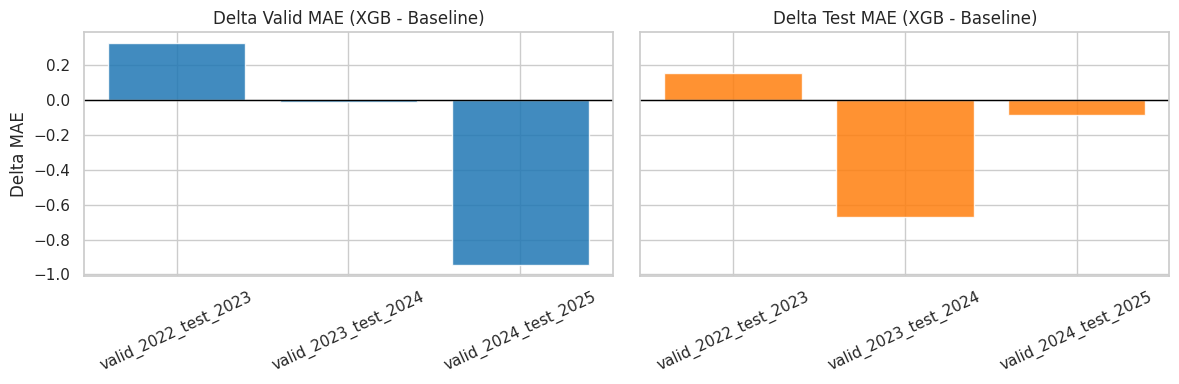

In [7]:
# Visual: delta MAE vs baseline by fold

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].bar(reg_eval["fold_name"], reg_eval["delta_valid_mae"], color="#1f77b4", alpha=0.85)
axes[0].axhline(0, color="black", lw=1)
axes[0].set_title("Delta Valid MAE (XGB - Baseline)")
axes[0].set_ylabel("Delta MAE")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(reg_eval["fold_name"], reg_eval["delta_test_mae"], color="#ff7f0e", alpha=0.85)
axes[1].axhline(0, color="black", lw=1)
axes[1].set_title("Delta Test MAE (XGB - Baseline)")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


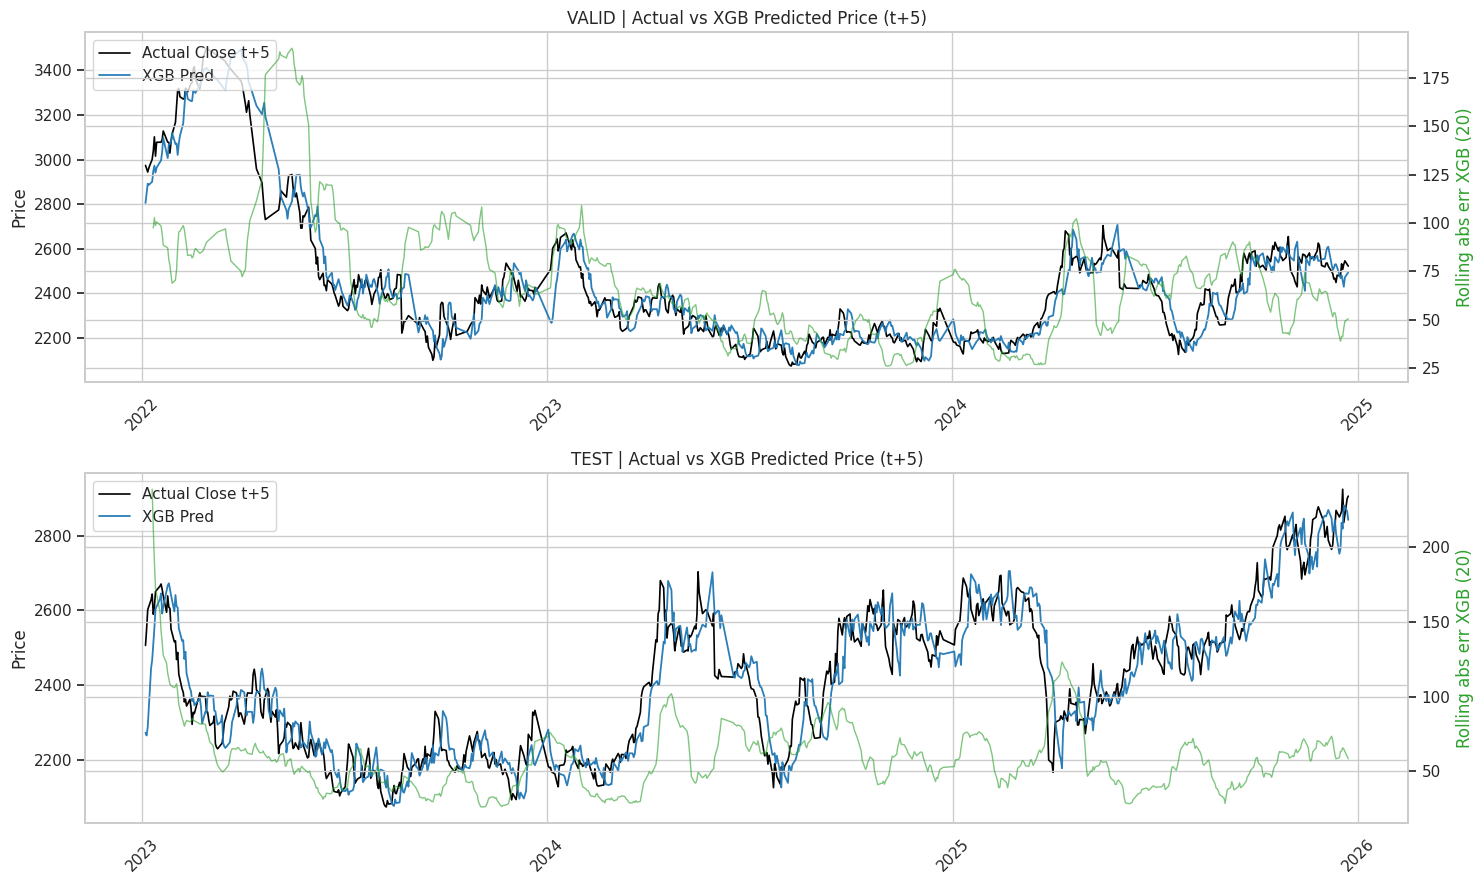

In [8]:
# Visual: actual vs predicted price over time (baseline hidden)

pred_df["Date"] = pd.to_datetime(pred_df["Date"])

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=False)
for ax, split in zip(axes, ["valid", "test"]):
    d = pred_df[pred_df["split"] == split].sort_values("Date")
    ax.plot(d["Date"], d["y_true_price_t5"], color="black", lw=1.2, label="Actual Close t+5")
    ax.plot(d["Date"], d["y_pred_price_t5"], color="#1f77b4", lw=1.3, alpha=0.95, label="XGB Pred")

    tmp = d.copy()
    tmp["abs_err_xgb"] = np.abs(tmp["y_true_price_t5"] - tmp["y_pred_price_t5"])
    ax2 = ax.twinx()
    ax2.plot(tmp["Date"], tmp["abs_err_xgb"].rolling(20, min_periods=5).mean(), color="#2ca02c", alpha=0.6, lw=1)
    ax2.set_ylabel("Rolling abs err XGB (20)", color="#2ca02c")

    ax.set_title(f"{split.upper()} | Actual vs XGB Predicted Price (t+5)")
    ax.set_ylabel("Price")
    ax.xaxis.set_major_locator(mdates.YearLocator(1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", rotation=45)
    ax.legend(loc="upper left")

plt.tight_layout()
plt.show()


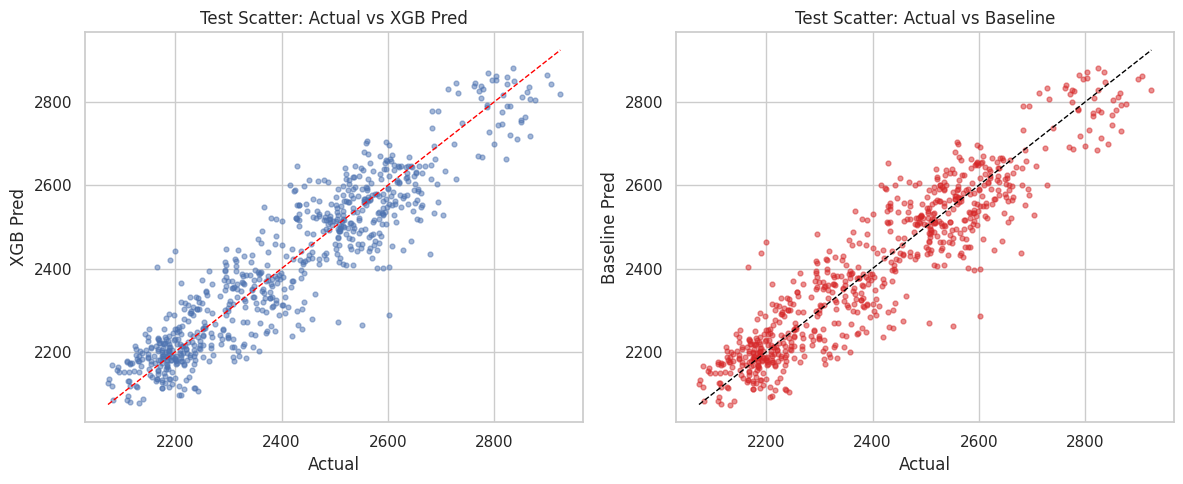

,test_corr_actual_xgb,test_corr_actual_baseline,test_mae_xgb,test_mae_baseline
0,0.927313,0.927299,57.885008,58.077387


In [9]:
# Visual: scatter + calibration toward baseline

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

te = pred_df[pred_df["split"] == "test"].copy()

axes[0].scatter(te["y_true_price_t5"], te["y_pred_price_t5"], s=12, alpha=0.5, label="XGB")
mn = min(te["y_true_price_t5"].min(), te["y_pred_price_t5"].min())
mx = max(te["y_true_price_t5"].max(), te["y_pred_price_t5"].max())
axes[0].plot([mn, mx], [mn, mx], "--", color="red", lw=1)
axes[0].set_title("Test Scatter: Actual vs XGB Pred")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("XGB Pred")

axes[1].scatter(te["y_true_price_t5"], te["baseline_price_t5"], s=12, alpha=0.5, label="Baseline", color="#d62728")
mn2 = min(te["y_true_price_t5"].min(), te["baseline_price_t5"].min())
mx2 = max(te["y_true_price_t5"].max(), te["baseline_price_t5"].max())
axes[1].plot([mn2, mx2], [mn2, mx2], "--", color="black", lw=1)
axes[1].set_title("Test Scatter: Actual vs Baseline")
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Baseline Pred")

plt.tight_layout()
plt.show()

corr_xgb = te[["y_true_price_t5", "y_pred_price_t5"]].corr().iloc[0, 1]
corr_base = te[["y_true_price_t5", "baseline_price_t5"]].corr().iloc[0, 1]

pd.DataFrame([
    {
        "test_corr_actual_xgb": float(corr_xgb),
        "test_corr_actual_baseline": float(corr_base),
        "test_mae_xgb": float(mean_absolute_error(te["y_true_price_t5"], te["y_pred_price_t5"])),
        "test_mae_baseline": float(mean_absolute_error(te["y_true_price_t5"], te["baseline_price_t5"])),
    }
])


In [10]:
# Final decision (price model)

leakage_pass = bool(leak_status == "PASS")
mean_delta_test = float(reg_eval["delta_test_mae"].mean())
per_fold_test_positive = bool((reg_eval["delta_test_mae"] < 0).all())
overall_go = bool(leakage_pass and robust_pass and (mean_delta_test < 0))

decision = {
    "target": f"close_t{H}",
    "model_type": "xgboost_regression_on_logret_then_to_price",
    "leakage_pass": leakage_pass,
    "robustness_pass": bool(robust_pass),
    "mean_delta_test_mae_negative": bool(mean_delta_test < 0),
    "all_folds_delta_test_mae_negative": per_fold_test_positive,
    "overall_go_price_model": overall_go,
    "mean_delta_test_mae": mean_delta_test,
    "mean_test_mape": float(reg_eval["xgb_test_mape"].mean()),
    "mean_test_dir_acc": float(reg_eval["xgb_test_dir_acc"].mean()),
    "feature_count": len(FEATURES),
}

pd.DataFrame([decision])


,target,model_type,leakage_pass,robustness_pass,mean_delta_test_mae_negative,all_folds_delta_test_mae_negative,overall_go_price_model,mean_delta_test_mae,mean_test_mape,mean_test_dir_acc,feature_count
0,close_t5,xgboost_regression_on_logret_then_to_price,True,True,True,False,True,-0.199547,0.023977,0.525973,17


In [11]:
# Save artifacts
# prefix = "xgb_v6_price_t5"

# reg_eval.to_csv(OUT_DIR / f"{prefix}_fold_results.csv", index=False)
# pred_df.to_csv(OUT_DIR / f"{prefix}_predictions.csv", index=False)
# audit_df.to_csv(OUT_DIR / f"{prefix}_leakage_audit.csv", index=False)
# viol_df.to_csv(OUT_DIR / f"{prefix}_leakage_violations.csv", index=False)
# summary.to_csv(OUT_DIR / f"{prefix}_summary.csv", index=False)
# robust.to_csv(OUT_DIR / f"{prefix}_robustness.csv", index=False)
# (OUT_DIR / f"{prefix}_decision.json").write_text(json.dumps(decision, indent=2))

# print("saved artifacts with prefix:", prefix)


saved artifacts with prefix: xgb_v6_price_t5


## Catatan Interpretasi

- Jika `overall_go_price_model=True`, model harga t+5 layak dipertimbangkan lanjut.
- Jika `False`, lebih aman pakai hasil directional sebagai sinyal utama, dan price forecast hanya sebagai skenario pendukung.
